# Liquid Analysis Visualization
Visualizes results from `liquid_analysis.py` — combining YOLO-NAS, Green HSV, Enhanced Green, and Baseline Residual detection.

**Data source:** `analysis_result/liquid_analysis.csv`

**Detection Methods:**
- **YOLO-NAS**: Bounding box detection of tips and liquid regions
- **Green HSV**: Standard green color segmentation within tip boxes
- **Enhanced Green**: CLAHE + saturation boost + wider HSV range for faint liquid
- **Baseline Residual**: Pixel-level comparison vs pick_up_tip (guaranteed empty) baseline

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Load data
CSV_PATH = "./analysis_result/liquid_analysis.csv"
IMAGE_DIR = "./analysis_result"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Loaded 40 rows, 96 columns


,filename,action,column,tips_detected,yolo_liquid_tips,green_liquid_tips,enhanced_liquid_tips,residual_liquid_tips,liquid_detected,confidence_score,...,avg_residual,tip_9_yolo_liquid,tip_9_yolo_fill,tip_9_yolo_conf,tip_9_green_ratio,tip_9_green_height,tip_9_enhanced_green,tip_9_edge_density,tip_9_baseline_diff,tip_9_residual
0,20260326_122126_095201_before_aspirate_col_A1_...,before_aspirate,A1,8,0,0,0,0,NO,0,...,0.0044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20260326_122222_669107_before_aspirate_col_A2_...,before_aspirate,A2,8,0,0,0,4,NO,0,...,0.0862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20260326_122318_895441_before_aspirate_col_A3_...,before_aspirate,A3,8,0,0,1,2,NO,0,...,0.0763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20260326_122415_279112_before_aspirate_col_A4_...,before_aspirate,A4,8,0,0,0,1,NO,0,...,0.0780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20260326_122511_343439_before_aspirate_col_A5_...,before_aspirate,A5,8,0,0,0,2,NO,0,...,0.0794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Overview: Liquid Detection Accuracy

Compare expected vs detected liquid presence across all 4 action types.

/var/folders/z4/_k3438wn743bnthnsfjyffqh0000gn/T/ipykernel_16285/581531127.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(accuracy.index, rotation=20, ha="right")


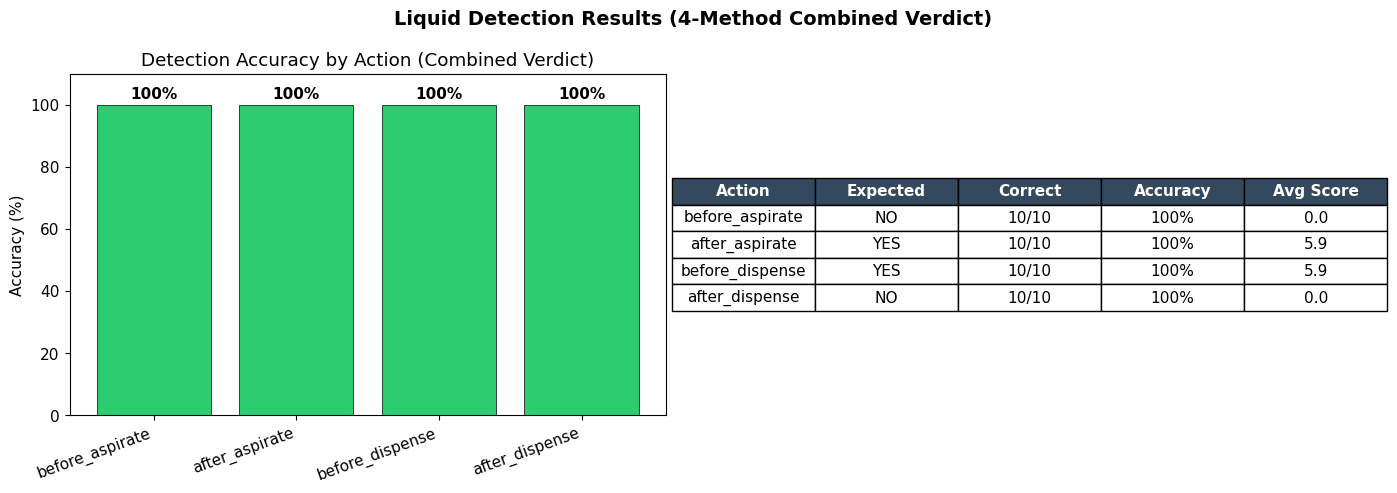


Overall Accuracy: 40/40 (100.0%)
Avg Confidence Score — Liquid images: 5.9, Empty images: 0.0


In [11]:
expected = {
    "before_aspirate": "NO",
    "after_aspirate": "YES",
    "before_dispense": "YES",
    "after_dispense": "NO",
}

df["expected"] = df["action"].map(expected)
df["correct"] = df["liquid_detected"] == df["expected"]

# Accuracy per action
accuracy = df.groupby("action")["correct"].mean() * 100
accuracy = accuracy.reindex(["before_aspirate", "after_aspirate", "before_dispense", "after_dispense"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: accuracy per action
colors = ["#2ecc71" if v == 100 else "#e74c3c" for v in accuracy.values]
bars = axes[0].bar(accuracy.index, accuracy.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Detection Accuracy by Action (Combined Verdict)")
axes[0].set_xticklabels(accuracy.index, rotation=20, ha="right")
for bar, val in zip(bars, accuracy.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"{val:.0f}%", ha="center", fontweight="bold")

# Confusion-style table with confidence scores
actions = ["before_aspirate", "after_aspirate", "before_dispense", "after_dispense"]
table_data = []
for action in actions:
    sub = df[df["action"] == action]
    total = len(sub)
    correct_n = sub["correct"].sum()
    avg_score = sub["confidence_score"].astype(float).mean() if "confidence_score" in df.columns else 0
    table_data.append([action, expected[action], f"{correct_n}/{total}", f"{correct_n/total*100:.0f}%", f"{avg_score:.1f}"])

axes[1].axis("off")
table = axes[1].table(
    cellText=table_data,
    colLabels=["Action", "Expected", "Correct", "Accuracy", "Avg Score"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for j in range(5):
    table[0, j].set_facecolor("#34495e")
    table[0, j].set_text_props(color="white", fontweight="bold")

plt.suptitle("Liquid Detection Results (4-Method Combined Verdict)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

overall = df["correct"].mean() * 100
print(f"\nOverall Accuracy: {df['correct'].sum()}/{len(df)} ({overall:.1f}%)")
if "confidence_score" in df.columns:
    print(f"Avg Confidence Score — Liquid images: {df[df['expected']=='YES']['confidence_score'].astype(float).mean():.1f}, Empty images: {df[df['expected']=='NO']['confidence_score'].astype(float).mean():.1f}")

## 2. YOLO Fill Ratio vs Green Ratio Across Columns

Shows how consistently each column was filled. Each column represents one transfer (A1 through A10+).

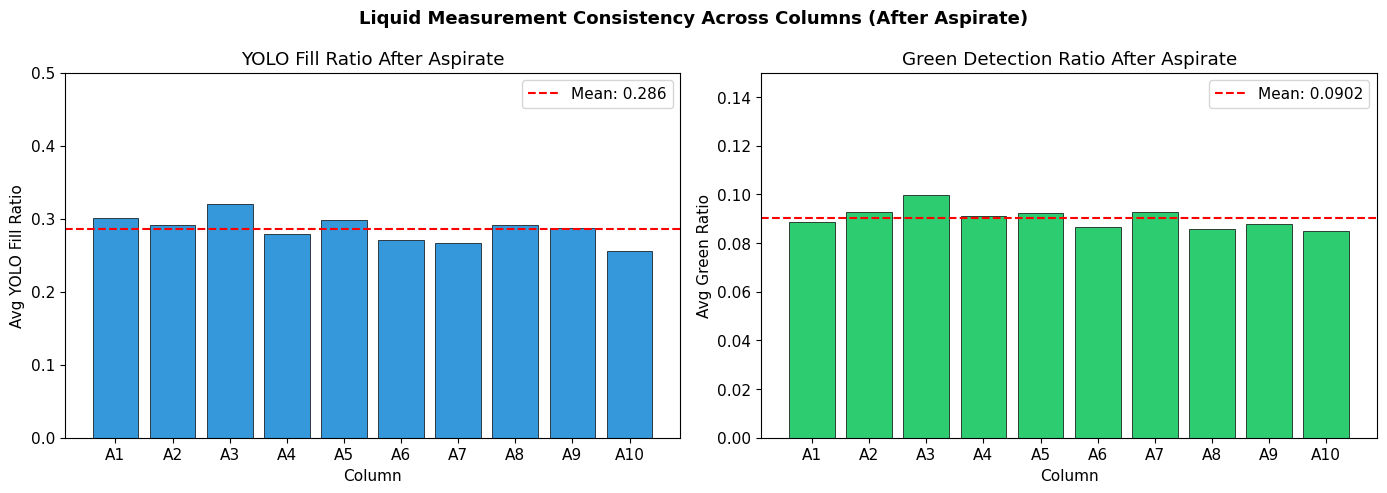

YOLO Fill — Mean: 0.2863, Std: 0.0188, CV: 6.6%
Green     — Mean: 0.0902, Std: 0.0044, CV: 4.9%


In [12]:
# Compare YOLO fill and green ratio for after_aspirate (liquid in tips)
aspirated = df[df["action"] == "after_aspirate"].copy()
aspirated = aspirated.sort_values("column", key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YOLO fill ratio per column
x = range(len(aspirated))
axes[0].bar(x, aspirated["avg_yolo_fill"].astype(float), color="#3498db", edgecolor="black", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(aspirated["column"], rotation=0)
axes[0].set_ylabel("Avg YOLO Fill Ratio")
axes[0].set_xlabel("Column")
axes[0].set_title("YOLO Fill Ratio After Aspirate")
axes[0].set_ylim(0, 0.5)
axes[0].axhline(y=aspirated["avg_yolo_fill"].astype(float).mean(), color="red", linestyle="--", label=f"Mean: {aspirated['avg_yolo_fill'].astype(float).mean():.3f}")
axes[0].legend()

# Green ratio per column
axes[1].bar(x, aspirated["avg_green"].astype(float), color="#2ecc71", edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(aspirated["column"], rotation=0)
axes[1].set_ylabel("Avg Green Ratio")
axes[1].set_xlabel("Column")
axes[1].set_title("Green Detection Ratio After Aspirate")
axes[1].set_ylim(0, 0.15)
axes[1].axhline(y=aspirated["avg_green"].astype(float).mean(), color="red", linestyle="--", label=f"Mean: {aspirated['avg_green'].astype(float).mean():.4f}")
axes[1].legend()

plt.suptitle("Liquid Measurement Consistency Across Columns (After Aspirate)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Stats
print(f"YOLO Fill — Mean: {aspirated['avg_yolo_fill'].astype(float).mean():.4f}, Std: {aspirated['avg_yolo_fill'].astype(float).std():.4f}, CV: {aspirated['avg_yolo_fill'].astype(float).std()/aspirated['avg_yolo_fill'].astype(float).mean()*100:.1f}%")
print(f"Green     — Mean: {aspirated['avg_green'].astype(float).mean():.4f}, Std: {aspirated['avg_green'].astype(float).std():.4f}, CV: {aspirated['avg_green'].astype(float).std()/aspirated['avg_green'].astype(float).mean()*100:.1f}%")

## 3. Per-Tip Uniformity (Tip 1–8)

Are all 8 tips picking up the same amount of liquid? This checks tip-to-tip consistency within each image.

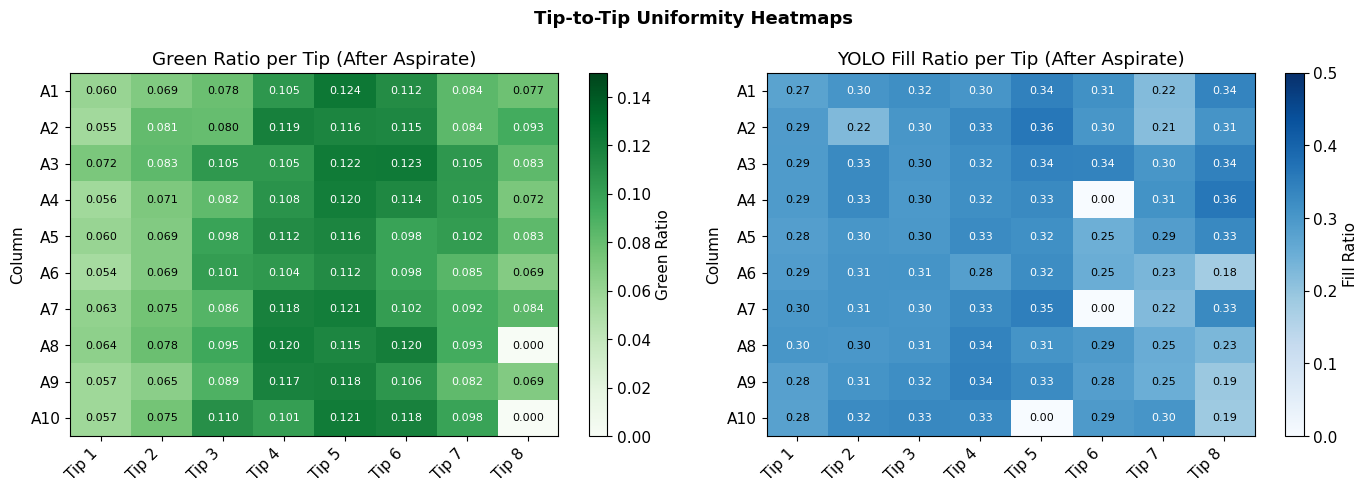

Per-tip average green ratio (across all columns):
  Tip 1: mean=0.0598, std=0.0054
  Tip 2: mean=0.0735, std=0.0058
  Tip 3: mean=0.0925, std=0.0110
  Tip 4: mean=0.1109, std=0.0073
  Tip 5: mean=0.1186, std=0.0037
  Tip 6: mean=0.1105, std=0.0090
  Tip 7: mean=0.0930, std=0.0092
  Tip 8: mean=0.0630, std=0.0341


In [13]:
# Per-tip green ratio for all after_aspirate images
aspirated = df[df["action"] == "after_aspirate"].copy()
aspirated = aspirated.sort_values("column", key=lambda x: x.str.extract(r'(\d+)')[0].astype(int))

tip_green_cols = [f"tip_{i}_green_ratio" for i in range(1, 9)]
tip_fill_cols = [f"tip_{i}_yolo_fill" for i in range(1, 9)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Green ratio heatmap
green_data = aspirated[tip_green_cols].astype(float).values
im1 = axes[0].imshow(green_data, cmap="Greens", aspect="auto", vmin=0, vmax=0.15)
axes[0].set_yticks(range(len(aspirated)))
axes[0].set_yticklabels(aspirated["column"].values)
axes[0].set_xticks(range(8))
axes[0].set_xticklabels([f"Tip {i}" for i in range(1, 9)], rotation=45, ha="right")
axes[0].set_title("Green Ratio per Tip (After Aspirate)")
axes[0].set_ylabel("Column")
plt.colorbar(im1, ax=axes[0], label="Green Ratio")

# Add text values
for i in range(green_data.shape[0]):
    for j in range(green_data.shape[1]):
        axes[0].text(j, i, f"{green_data[i,j]:.3f}", ha="center", va="center", fontsize=8,
                     color="white" if green_data[i,j] > 0.08 else "black")

# YOLO fill heatmap
fill_data = aspirated[tip_fill_cols].astype(float).values
im2 = axes[1].imshow(fill_data, cmap="Blues", aspect="auto", vmin=0, vmax=0.5)
axes[1].set_yticks(range(len(aspirated)))
axes[1].set_yticklabels(aspirated["column"].values)
axes[1].set_xticks(range(8))
axes[1].set_xticklabels([f"Tip {i}" for i in range(1, 9)], rotation=45, ha="right")
axes[1].set_title("YOLO Fill Ratio per Tip (After Aspirate)")
axes[1].set_ylabel("Column")
plt.colorbar(im2, ax=axes[1], label="Fill Ratio")

for i in range(fill_data.shape[0]):
    for j in range(fill_data.shape[1]):
        axes[1].text(j, i, f"{fill_data[i,j]:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if fill_data[i,j] > 0.3 else "black")

plt.suptitle("Tip-to-Tip Uniformity Heatmaps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Per-tip stats
print("Per-tip average green ratio (across all columns):")
for i in range(1, 9):
    col = f"tip_{i}_green_ratio"
    vals = aspirated[col].astype(float)
    print(f"  Tip {i}: mean={vals.mean():.4f}, std={vals.std():.4f}")

## 4. Before vs After Comparison

Shows the signal change between before and after aspirate/dispense. A good protocol should show a clear jump.

/var/folders/z4/_k3438wn743bnthnsfjyffqh0000gn/T/ipykernel_16285/677383005.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0, 0].boxplot(green_by_action, labels=action_labels, patch_artist=True, widths=0.6)
/var/folders/z4/_k3438wn743bnthnsfjyffqh0000gn/T/ipykernel_16285/677383005.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0, 1].boxplot(fill_by_action, labels=action_labels, patch_artist=True, widths=0.6)
/var/folders/z4/_k3438wn743bnthnsfjyffqh0000gn/T/ipykernel_16285/677383005.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[1, 0].boxplot(enh_by_action, labels=actio

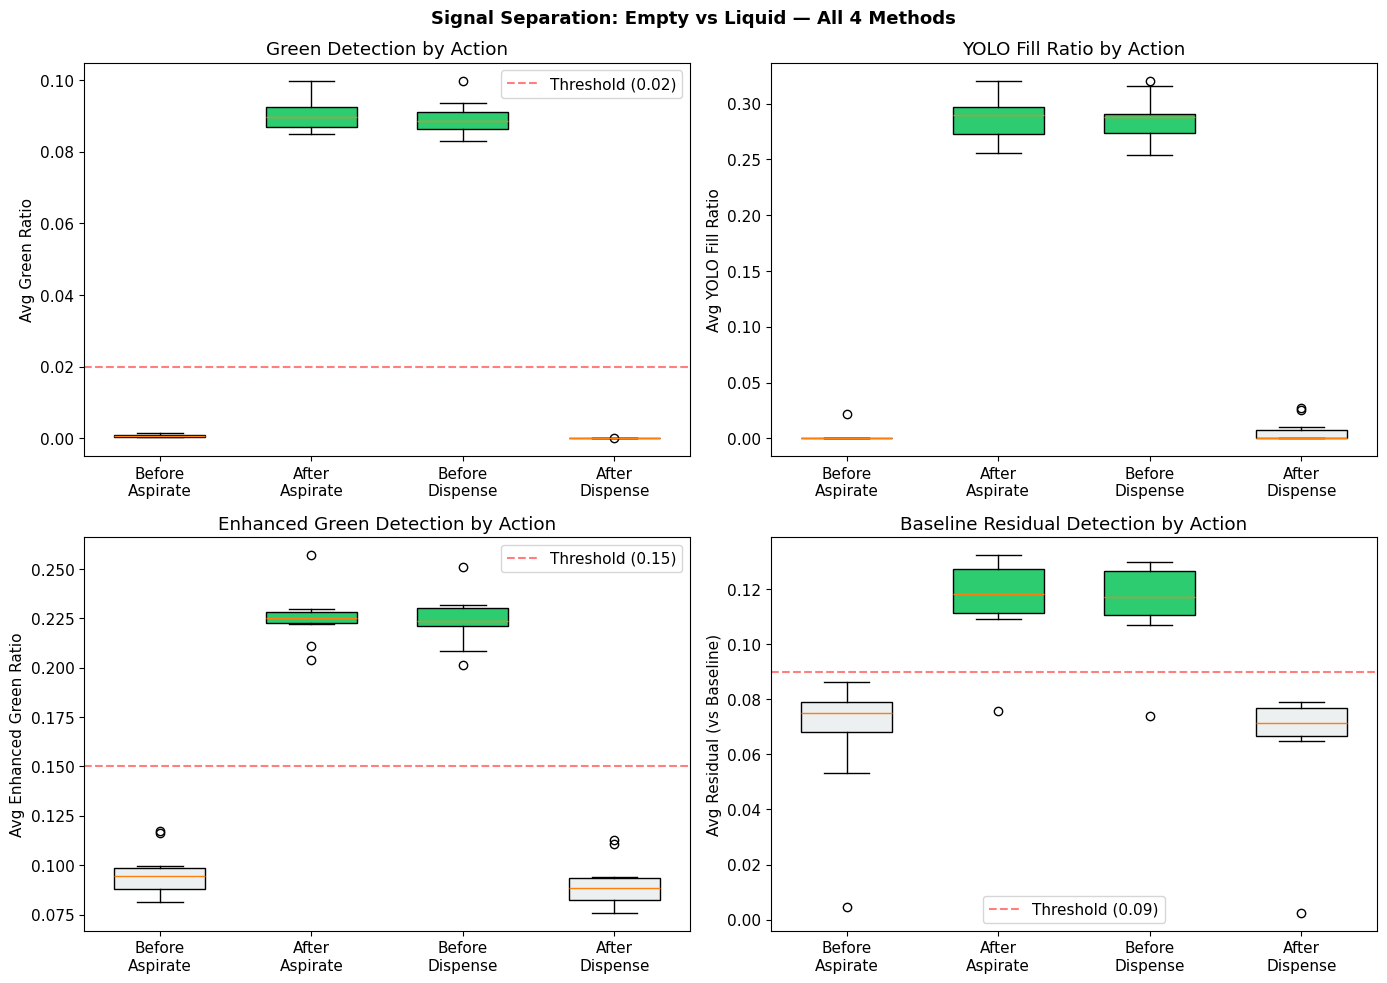

Green           : empty max=0.0015, liquid min=0.0829, gap=0.0814 (CLEAR) [threshold=0.02]
YOLO Fill       : empty max=0.0271, liquid min=0.2536, gap=0.2265 (CLEAR) [threshold=0.05]
Enhanced Green  : empty max=0.1175, liquid min=0.2014, gap=0.0839 (CLEAR) [threshold=0.15]
Residual        : empty max=0.0862, liquid min=0.0741, gap=-0.0121 (OVERLAP) [threshold=0.09]


In [14]:
# Group by action and show distributions
actions_order = ["before_aspirate", "after_aspirate", "before_dispense", "after_dispense"]
action_labels = ["Before\nAspirate", "After\nAspirate", "Before\nDispense", "After\nDispense"]
action_colors = ["#ecf0f1", "#2ecc71", "#2ecc71", "#ecf0f1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Green ratio by action
green_by_action = [df[df["action"] == a]["avg_green"].astype(float).values for a in actions_order]
bp1 = axes[0, 0].boxplot(green_by_action, labels=action_labels, patch_artist=True, widths=0.6)
for patch, color in zip(bp1["boxes"], action_colors):
    patch.set_facecolor(color)
axes[0, 0].set_ylabel("Avg Green Ratio")
axes[0, 0].set_title("Green Detection by Action")
axes[0, 0].axhline(y=0.02, color="red", linestyle="--", alpha=0.5, label="Threshold (0.02)")
axes[0, 0].legend()

# YOLO fill by action
fill_by_action = [df[df["action"] == a]["avg_yolo_fill"].astype(float).values for a in actions_order]
bp2 = axes[0, 1].boxplot(fill_by_action, labels=action_labels, patch_artist=True, widths=0.6)
for patch, color in zip(bp2["boxes"], action_colors):
    patch.set_facecolor(color)
axes[0, 1].set_ylabel("Avg YOLO Fill Ratio")
axes[0, 1].set_title("YOLO Fill Ratio by Action")

# Enhanced green by action
if "avg_enhanced_green" in df.columns:
    enh_by_action = [df[df["action"] == a]["avg_enhanced_green"].astype(float).values for a in actions_order]
    bp3 = axes[1, 0].boxplot(enh_by_action, labels=action_labels, patch_artist=True, widths=0.6)
    for patch, color in zip(bp3["boxes"], action_colors):
        patch.set_facecolor(color)
    axes[1, 0].set_ylabel("Avg Enhanced Green Ratio")
    axes[1, 0].set_title("Enhanced Green Detection by Action")
    axes[1, 0].axhline(y=0.15, color="red", linestyle="--", alpha=0.5, label="Threshold (0.15)")
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, "No enhanced green data", ha="center", va="center", transform=axes[1, 0].transAxes)

# Residual by action
if "avg_residual" in df.columns:
    resid_by_action = [df[df["action"] == a]["avg_residual"].astype(float).values for a in actions_order]
    bp4 = axes[1, 1].boxplot(resid_by_action, labels=action_labels, patch_artist=True, widths=0.6)
    for patch, color in zip(bp4["boxes"], action_colors):
        patch.set_facecolor(color)
    axes[1, 1].set_ylabel("Avg Residual (vs Baseline)")
    axes[1, 1].set_title("Baseline Residual Detection by Action")
    axes[1, 1].axhline(y=0.09, color="red", linestyle="--", alpha=0.5, label="Threshold (0.09)")
    axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, "No residual data", ha="center", va="center", transform=axes[1, 1].transAxes)

plt.suptitle("Signal Separation: Empty vs Liquid — All 4 Methods", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Separation stats for all methods
metrics = [
    ("avg_green", "Green", 0.02),
    ("avg_yolo_fill", "YOLO Fill", 0.05),
    ("avg_enhanced_green", "Enhanced Green", 0.15),
    ("avg_residual", "Residual", 0.09),
]
for metric, name, thresh in metrics:
    if metric not in df.columns:
        continue
    empty = df[df["action"].isin(["before_aspirate", "after_dispense"])][metric].astype(float)
    liquid = df[df["action"].isin(["after_aspirate", "before_dispense"])][metric].astype(float)
    gap = liquid.min() - empty.max()
    print(f"{name:16s}: empty max={empty.max():.4f}, liquid min={liquid.min():.4f}, gap={gap:.4f} ({'CLEAR' if gap > 0 else 'OVERLAP'}) [threshold={thresh}]")

## 5. All 4 Methods Comparison

Scatter and bar plots comparing YOLO, Green, Enhanced Green, and Baseline Residual detection. Good methods should clearly separate liquid from empty images.

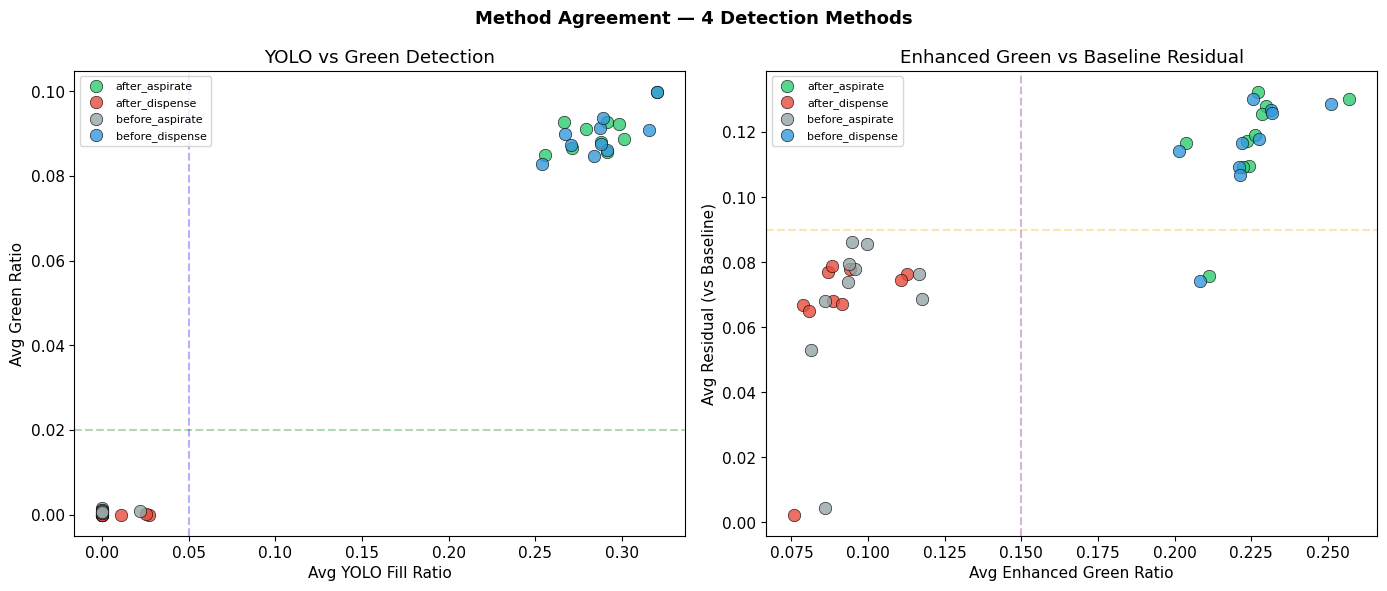

Method agreement rates:
  yolo vs green: 90.0% agreement
  yolo vs enhanced: 90.0% agreement
  yolo vs residual: 85.0% agreement
  green vs enhanced: 100.0% agreement
  green vs residual: 95.0% agreement
  enhanced vs residual: 95.0% agreement


In [15]:
# Scatter: YOLO fill vs Green ratio (colored by action)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {
    "before_aspirate": "#95a5a6",
    "after_aspirate": "#2ecc71",
    "before_dispense": "#3498db",
    "after_dispense": "#e74c3c",
}

# Plot 1: YOLO vs Green
for action, group in df.groupby("action"):
    axes[0].scatter(
        group["avg_yolo_fill"].astype(float),
        group["avg_green"].astype(float),
        label=action, color=colors_map[action],
        s=80, edgecolors="black", linewidth=0.5, alpha=0.8,
    )
axes[0].set_xlabel("Avg YOLO Fill Ratio")
axes[0].set_ylabel("Avg Green Ratio")
axes[0].set_title("YOLO vs Green Detection")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].axhline(y=0.02, color="green", linestyle="--", alpha=0.3)
axes[0].axvline(x=0.05, color="blue", linestyle="--", alpha=0.3)

# Plot 2: Enhanced Green vs Residual
if "avg_enhanced_green" in df.columns and "avg_residual" in df.columns:
    for action, group in df.groupby("action"):
        axes[1].scatter(
            group["avg_enhanced_green"].astype(float),
            group["avg_residual"].astype(float),
            label=action, color=colors_map[action],
            s=80, edgecolors="black", linewidth=0.5, alpha=0.8,
        )
    axes[1].set_xlabel("Avg Enhanced Green Ratio")
    axes[1].set_ylabel("Avg Residual (vs Baseline)")
    axes[1].set_title("Enhanced Green vs Baseline Residual")
    axes[1].legend(loc="upper left", fontsize=8)
    axes[1].axhline(y=0.09, color="orange", linestyle="--", alpha=0.3, label="Residual threshold")
    axes[1].axvline(x=0.15, color="purple", linestyle="--", alpha=0.3, label="Enhanced threshold")

plt.suptitle("Method Agreement — 4 Detection Methods", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Method agreement
df["yolo_says"] = df["yolo_liquid_tips"].astype(int) > 0
df["green_says"] = df["avg_green"].astype(float) > 0.02
if "avg_enhanced_green" in df.columns:
    df["enhanced_says"] = df["avg_enhanced_green"].astype(float) > 0.15
if "avg_residual" in df.columns:
    df["residual_says"] = df["avg_residual"].astype(float) > 0.09

methods = ["yolo_says", "green_says"]
if "enhanced_says" in df.columns:
    methods.append("enhanced_says")
if "residual_says" in df.columns:
    methods.append("residual_says")

print("Method agreement rates:")
for i, m1 in enumerate(methods):
    for m2 in methods[i+1:]:
        agree = (df[m1] == df[m2]).mean() * 100
        print(f"  {m1.replace('_says','')} vs {m2.replace('_says','')}: {agree:.1f}% agreement")

## 6. Confidence Score Breakdown

Shows how the multi-method confidence scoring works. Each method contributes points:
- Green > 0.02 → +2pts | YOLO majority → +2pts | Enhanced > 0.15 → +1pt | Residual > 0.09 → +1pt
- **Verdict: score >= 2 → LIQUID**

/var/folders/z4/_k3438wn743bnthnsfjyffqh0000gn/T/ipykernel_16285/3304328939.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(actions_order, rotation=20, ha="right")


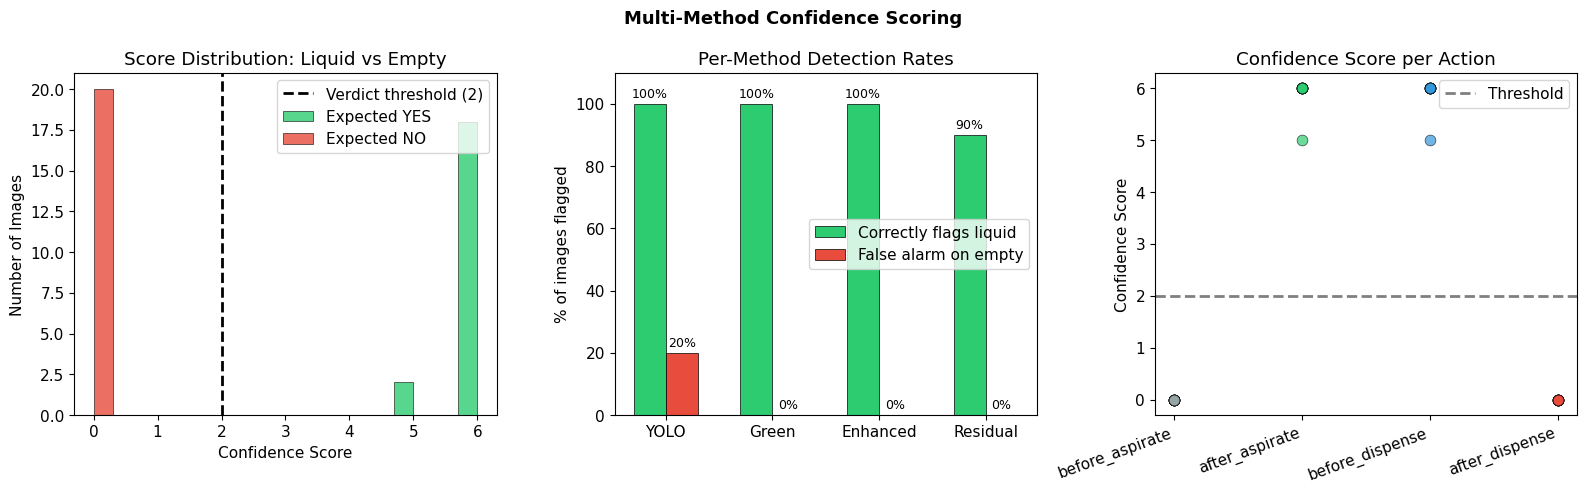

In [16]:
if "confidence_score" in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Confidence score distribution by expected label
    for label, color, offset in [("YES", "#2ecc71", -0.15), ("NO", "#e74c3c", 0.15)]:
        sub = df[df["expected"] == label]
        scores = sub["confidence_score"].astype(float)
        score_counts = scores.value_counts().sort_index()
        axes[0].bar(score_counts.index + offset, score_counts.values, width=0.3,
                    color=color, edgecolor="black", linewidth=0.5, label=f"Expected {label}", alpha=0.8)
    axes[0].axvline(x=2, color="black", linestyle="--", linewidth=2, label="Verdict threshold (2)")
    axes[0].set_xlabel("Confidence Score")
    axes[0].set_ylabel("Number of Images")
    axes[0].set_title("Score Distribution: Liquid vs Empty")
    axes[0].legend()
    axes[0].set_xticks(range(0, 7))

    # 2. Per-method contribution — what fraction of "liquid" images did each method catch?
    liquid_imgs = df[df["expected"] == "YES"]
    empty_imgs = df[df["expected"] == "NO"]

    method_names = ["YOLO", "Green", "Enhanced", "Residual"]
    liquid_rates = []
    empty_rates = []
    for col in ["yolo_says", "green_says", "enhanced_says", "residual_says"]:
        if col in df.columns:
            liquid_rates.append(liquid_imgs[col].mean() * 100)
            empty_rates.append(empty_imgs[col].mean() * 100)
        else:
            liquid_rates.append(0)
            empty_rates.append(0)

    x = np.arange(len(method_names))
    axes[1].bar(x - 0.15, liquid_rates, 0.3, label="Correctly flags liquid", color="#2ecc71", edgecolor="black", linewidth=0.5)
    axes[1].bar(x + 0.15, empty_rates, 0.3, label="False alarm on empty", color="#e74c3c", edgecolor="black", linewidth=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(method_names)
    axes[1].set_ylabel("% of images flagged")
    axes[1].set_title("Per-Method Detection Rates")
    axes[1].legend()
    axes[1].set_ylim(0, 110)
    for i, (lr, er) in enumerate(zip(liquid_rates, empty_rates)):
        axes[1].text(i - 0.15, lr + 2, f"{lr:.0f}%", ha="center", fontsize=9)
        axes[1].text(i + 0.15, er + 2, f"{er:.0f}%", ha="center", fontsize=9)

    # 3. Confidence score per action
    for action in actions_order:
        sub = df[df["action"] == action]
        axes[2].scatter([action]*len(sub), sub["confidence_score"].astype(float),
                       color=colors_map[action], s=60, edgecolors="black", linewidth=0.5, alpha=0.7)
    axes[2].axhline(y=2, color="black", linestyle="--", linewidth=2, alpha=0.5, label="Threshold")
    axes[2].set_ylabel("Confidence Score")
    axes[2].set_title("Confidence Score per Action")
    axes[2].set_xticklabels(actions_order, rotation=20, ha="right")
    axes[2].legend()

    plt.suptitle("Multi-Method Confidence Scoring", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No confidence_score column found — run updated liquid_analysis.py first")

## 7. Timeline View

Shows all 4 metrics over time (image sequence) to see the aspirate/dispense cycle pattern.

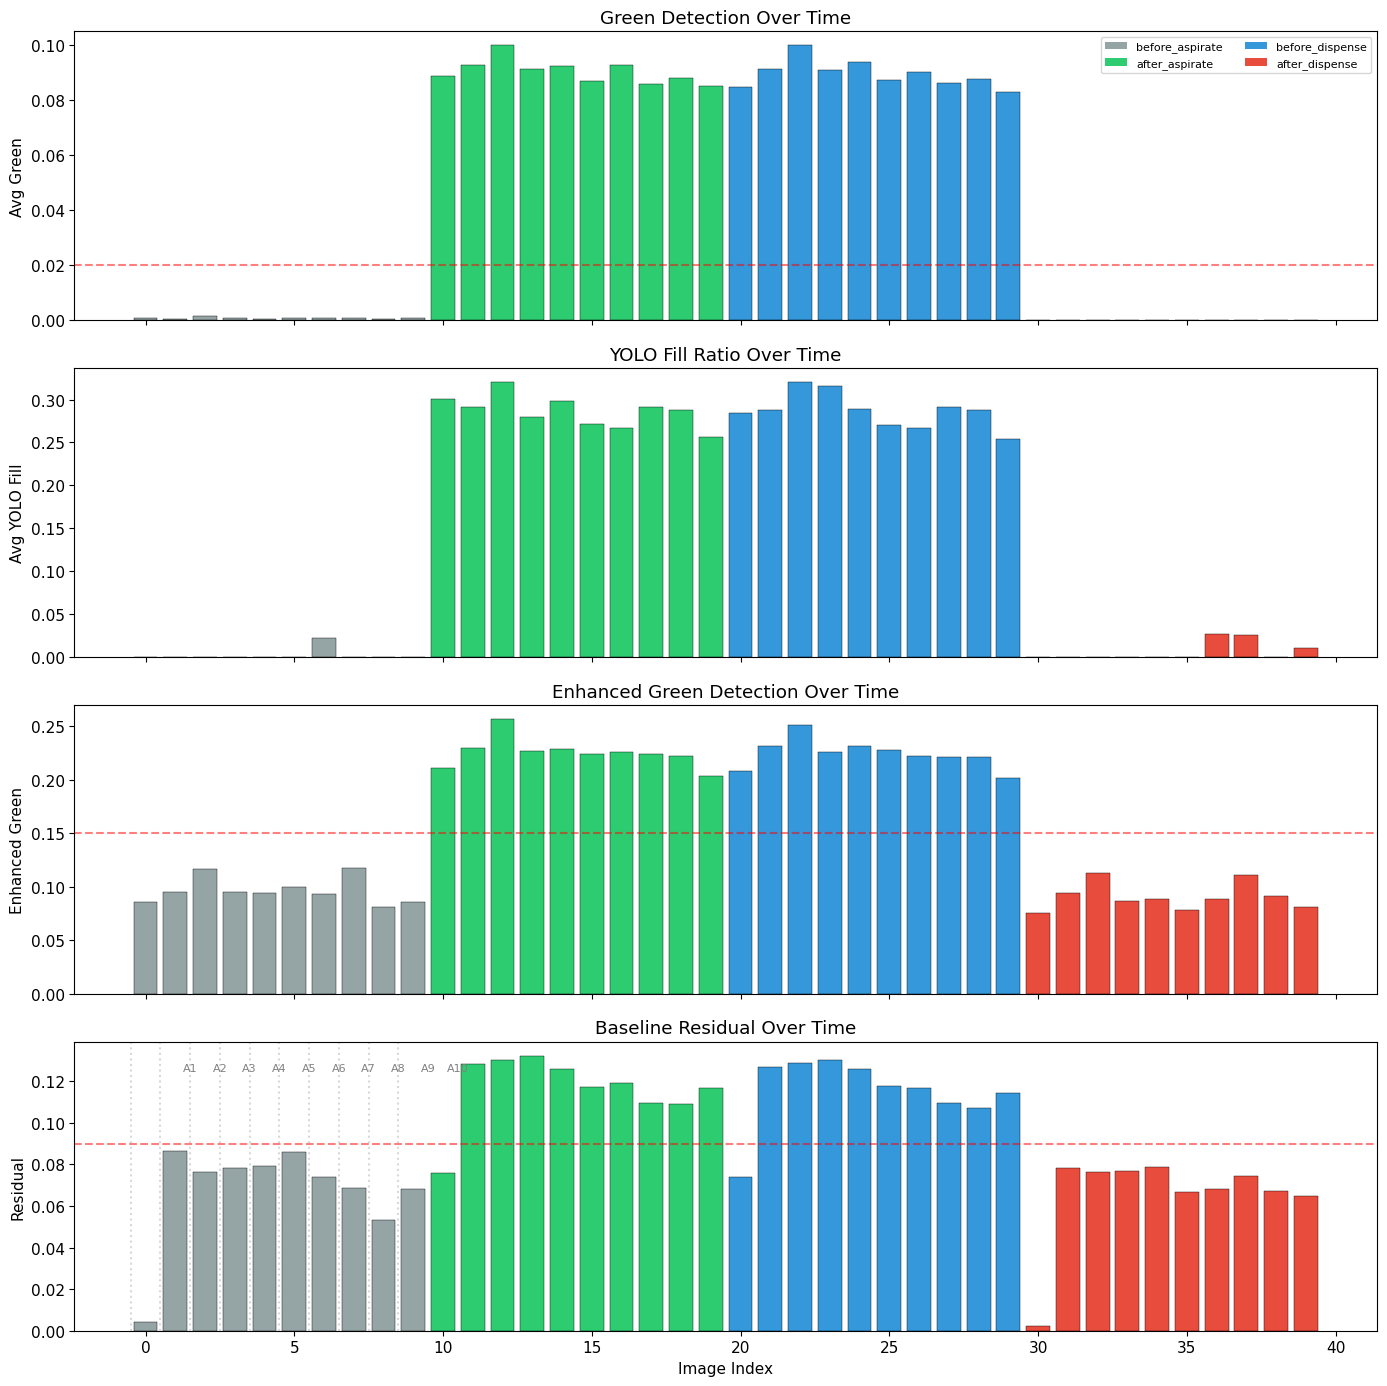

In [17]:
# Timeline: all 4 metrics over image sequence
n_metrics = 2 + ("avg_enhanced_green" in df.columns) + ("avg_residual" in df.columns)
fig, axes = plt.subplots(n_metrics, 1, figsize=(14, 3.5 * n_metrics), sharex=True)
if n_metrics == 1:
    axes = [axes]

x = range(len(df))
action_colors_seq = [colors_map[a] for a in df["action"]]

plot_idx = 0

# Green ratio timeline
axes[plot_idx].bar(x, df["avg_green"].astype(float), color=action_colors_seq, edgecolor="black", linewidth=0.3)
axes[plot_idx].axhline(y=0.02, color="red", linestyle="--", alpha=0.5)
axes[plot_idx].set_ylabel("Avg Green")
axes[plot_idx].set_title("Green Detection Over Time")
plot_idx += 1

# YOLO fill timeline
axes[plot_idx].bar(x, df["avg_yolo_fill"].astype(float), color=action_colors_seq, edgecolor="black", linewidth=0.3)
axes[plot_idx].set_ylabel("Avg YOLO Fill")
axes[plot_idx].set_title("YOLO Fill Ratio Over Time")
plot_idx += 1

# Enhanced green timeline
if "avg_enhanced_green" in df.columns:
    axes[plot_idx].bar(x, df["avg_enhanced_green"].astype(float), color=action_colors_seq, edgecolor="black", linewidth=0.3)
    axes[plot_idx].axhline(y=0.15, color="red", linestyle="--", alpha=0.5)
    axes[plot_idx].set_ylabel("Enhanced Green")
    axes[plot_idx].set_title("Enhanced Green Detection Over Time")
    plot_idx += 1

# Residual timeline
if "avg_residual" in df.columns:
    axes[plot_idx].bar(x, df["avg_residual"].astype(float), color=action_colors_seq, edgecolor="black", linewidth=0.3)
    axes[plot_idx].axhline(y=0.09, color="red", linestyle="--", alpha=0.5)
    axes[plot_idx].set_ylabel("Residual")
    axes[plot_idx].set_title("Baseline Residual Over Time")
    plot_idx += 1

# Add column labels
last_ax = axes[-1]
last_ax.set_xlabel("Image Index")
for i, (_, row) in enumerate(df.iterrows()):
    if row["action"] == "before_aspirate":
        last_ax.axvline(x=i-0.5, color="gray", linestyle=":", alpha=0.3)
        last_ax.text(i+1.5, last_ax.get_ylim()[1]*0.9, row["column"],
                     ha="center", fontsize=8, color="gray")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=a) for a, c in colors_map.items()]
axes[0].legend(handles=legend_elements, loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 8. Sample Annotated vs Enhanced Images

Side-by-side comparison of annotated (original) and enhanced (CLAHE + saturation boost) images.

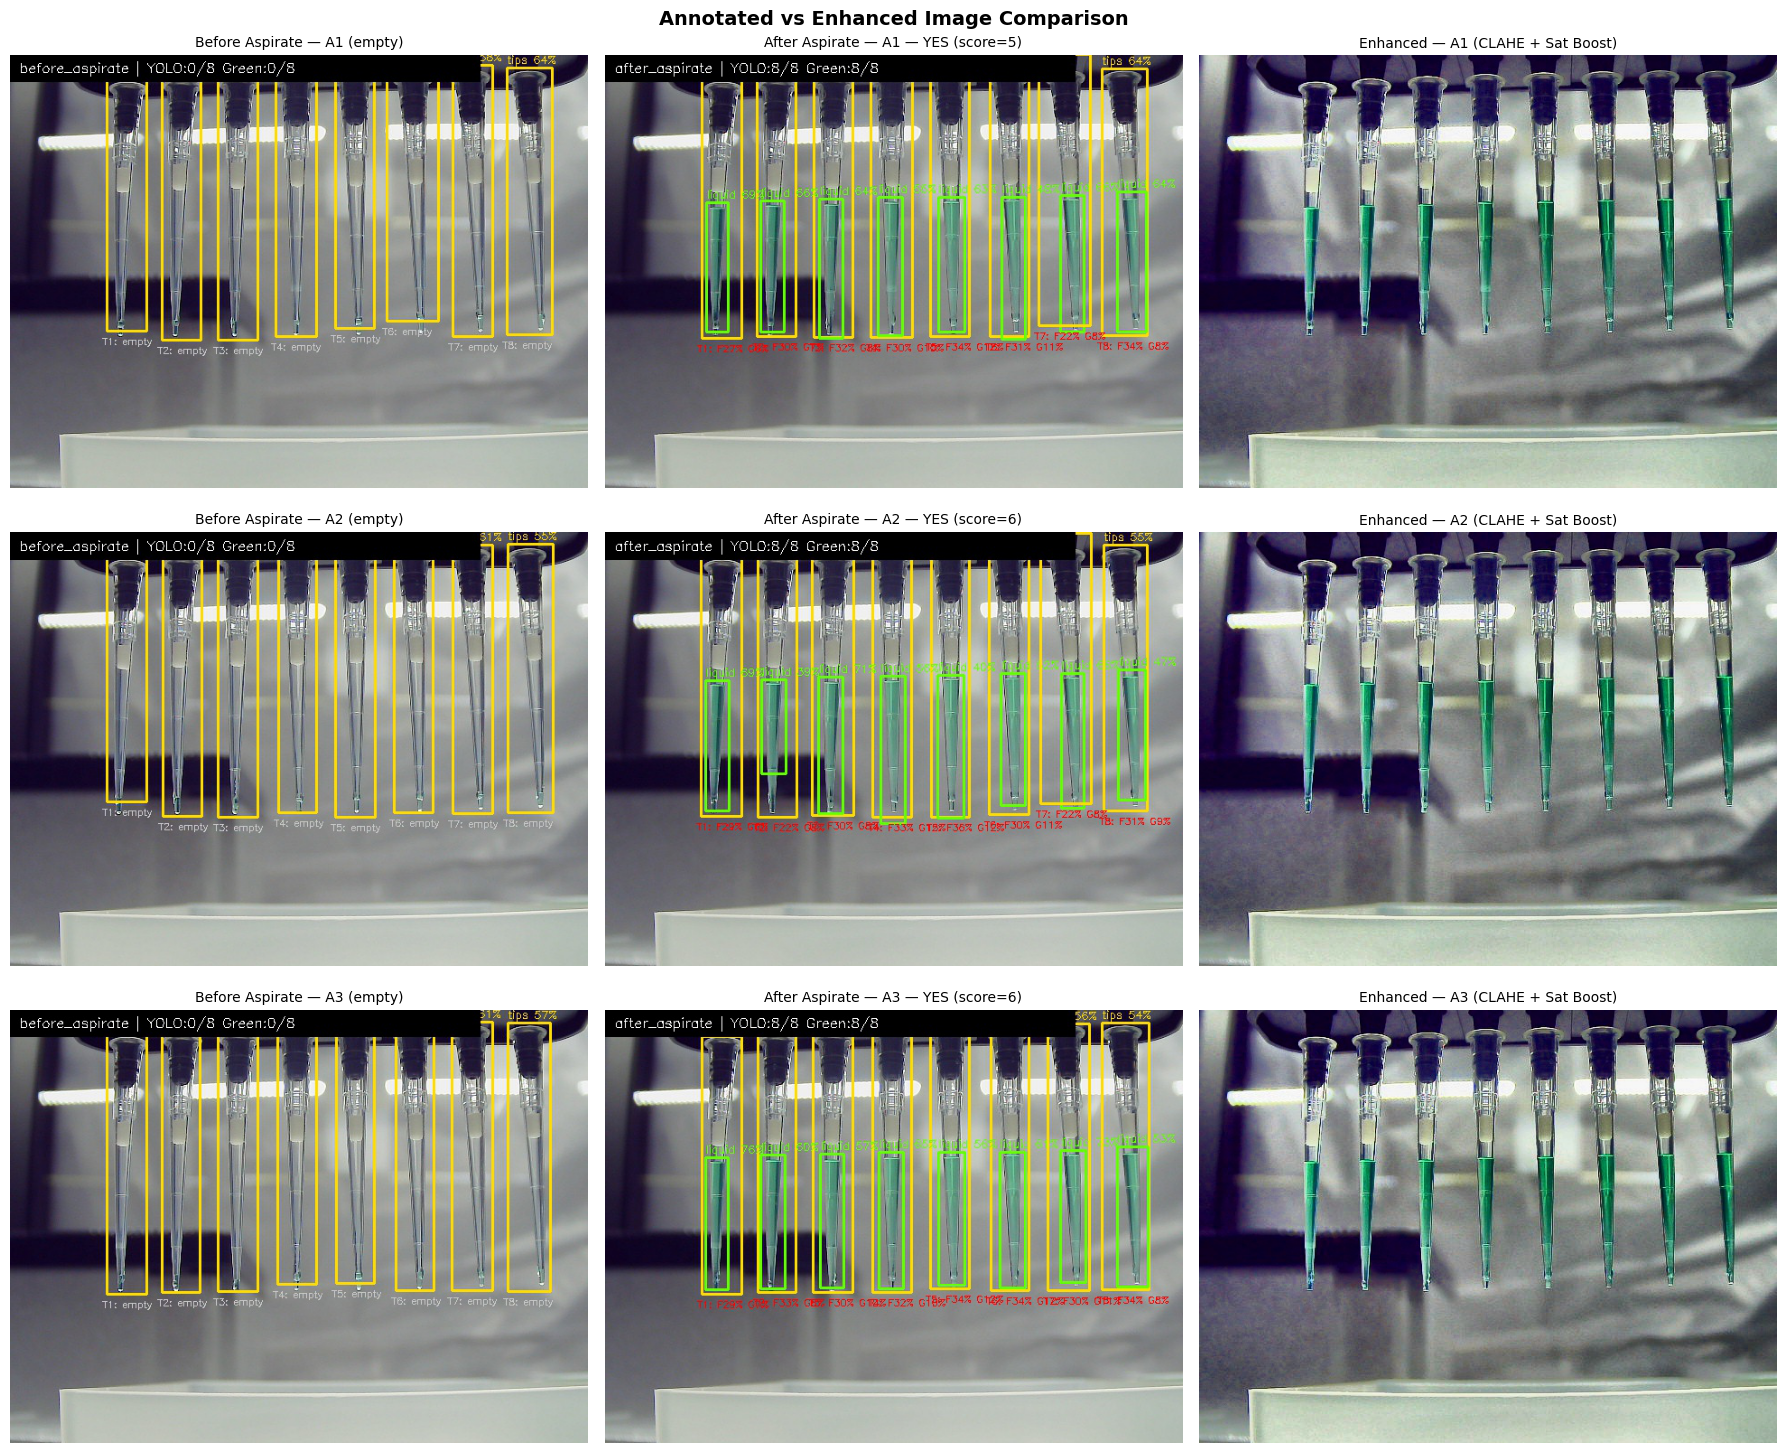

In [18]:
# Show annotated + enhanced images for first 3 columns (before vs after aspirate)
cols_to_show = ["A1", "A2", "A3"]
fig, axes = plt.subplots(len(cols_to_show), 3, figsize=(18, 5 * len(cols_to_show)))

for row_idx, col in enumerate(cols_to_show):
    # Before aspirate (annotated)
    sub = df[(df["action"] == "before_aspirate") & (df["column"] == col)]
    if len(sub) > 0:
        fname = sub.iloc[0]["filename"]
        img_path = os.path.join(IMAGE_DIR, f"annotated_{fname}")
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[row_idx, 0].imshow(img)
            axes[row_idx, 0].set_title(f"Before Aspirate — {col} (empty)", fontsize=10)
        axes[row_idx, 0].axis("off")

    # After aspirate (annotated)
    sub = df[(df["action"] == "after_aspirate") & (df["column"] == col)]
    if len(sub) > 0:
        fname = sub.iloc[0]["filename"]
        img_path = os.path.join(IMAGE_DIR, f"annotated_{fname}")
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[row_idx, 1].imshow(img)
            verdict = sub.iloc[0]["liquid_detected"]
            score = sub.iloc[0]["confidence_score"] if "confidence_score" in sub.columns else "?"
            axes[row_idx, 1].set_title(f"After Aspirate — {col} — {verdict} (score={score})", fontsize=10)
        axes[row_idx, 1].axis("off")

        # After aspirate (enhanced)
        enh_path = os.path.join(IMAGE_DIR, f"enhanced_{fname}")
        if os.path.exists(enh_path):
            enh = mpimg.imread(enh_path)
            axes[row_idx, 2].imshow(enh)
            axes[row_idx, 2].set_title(f"Enhanced — {col} (CLAHE + Sat Boost)", fontsize=10)
        else:
            axes[row_idx, 2].text(0.5, 0.5, "No enhanced image", ha="center", va="center",
                                   transform=axes[row_idx, 2].transAxes)
        axes[row_idx, 2].axis("off")

plt.suptitle("Annotated vs Enhanced Image Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Summary Statistics — All Methods

In [19]:
# Full summary statistics table
print("=" * 80)
print("FULL SUMMARY — ALL 4 DETECTION METHODS")
print("=" * 80)

summary_data = []
for action in actions_order:
    sub = df[df["action"] == action]
    n = len(sub)
    correct_n = sub["correct"].sum()
    
    row_data = {
        "Action": action,
        "Expected": expected[action],
        "Accuracy": f"{correct_n}/{n} ({correct_n/n*100:.0f}%)",
        "YOLO Fill": f"{sub['avg_yolo_fill'].astype(float).mean():.4f}",
        "Green": f"{sub['avg_green'].astype(float).mean():.4f}",
    }
    if "avg_enhanced_green" in df.columns:
        row_data["Enhanced"] = f"{sub['avg_enhanced_green'].astype(float).mean():.4f}"
    if "avg_residual" in df.columns:
        row_data["Residual"] = f"{sub['avg_residual'].astype(float).mean():.4f}"
    if "confidence_score" in df.columns:
        row_data["Avg Score"] = f"{sub['confidence_score'].astype(float).mean():.1f}"
    
    summary_data.append(row_data)

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{"text-align": "center"}).hide(axis="index"))

print(f"\nOverall Detection Accuracy: {df['correct'].sum()}/{len(df)} ({df['correct'].mean()*100:.1f}%)")

# Per-method accuracy (if each method were used alone)
print("\n--- Per-Method Solo Accuracy (if used alone) ---")
method_checks = [
    ("YOLO", lambda r: ("YES" if int(r["yolo_liquid_tips"]) > int(r["tips_detected"]) // 2 else "NO")),
    ("Green", lambda r: ("YES" if float(r["avg_green"]) > 0.02 else "NO")),
]
if "avg_enhanced_green" in df.columns:
    method_checks.append(("Enhanced", lambda r: ("YES" if float(r["avg_enhanced_green"]) > 0.15 else "NO")))
if "avg_residual" in df.columns:
    method_checks.append(("Residual", lambda r: ("YES" if float(r["avg_residual"]) > 0.09 else "NO")))

for name, fn in method_checks:
    correct = sum(1 for _, r in df.iterrows() if fn(r) == r["expected"])
    print(f"  {name:12s}: {correct}/{len(df)} ({correct/len(df)*100:.1f}%)")

print(f"  {'Combined':12s}: {df['correct'].sum()}/{len(df)} ({df['correct'].mean()*100:.1f}%)")

# Aspirate consistency
asp = df[df["action"] == "after_aspirate"]
if len(asp) > 1:
    print("\n--- Aspirate Consistency (lower CV = more uniform) ---")
    for metric, name in [("avg_yolo_fill", "YOLO Fill"), ("avg_green", "Green")]:
        vals = asp[metric].astype(float)
        cv = vals.std() / vals.mean() * 100 if vals.mean() > 0 else 0
        print(f"  {name}: mean={vals.mean():.4f}, std={vals.std():.4f}, CV={cv:.1f}%")
    if "avg_enhanced_green" in df.columns:
        vals = asp["avg_enhanced_green"].astype(float)
        cv = vals.std() / vals.mean() * 100 if vals.mean() > 0 else 0
        print(f"  Enhanced: mean={vals.mean():.4f}, std={vals.std():.4f}, CV={cv:.1f}%")
    if "avg_residual" in df.columns:
        vals = asp["avg_residual"].astype(float)
        cv = vals.std() / vals.mean() * 100 if vals.mean() > 0 else 0
        print(f"  Residual: mean={vals.mean():.4f}, std={vals.std():.4f}, CV={cv:.1f}%")

FULL SUMMARY — ALL 4 DETECTION METHODS


Action,Expected,Accuracy,YOLO Fill,Green,Enhanced,Residual,Avg Score
before_aspirate,NO,10/10 (100%),0.0022,0.0008,0.0965,0.0674,0.0
after_aspirate,YES,10/10 (100%),0.2863,0.0902,0.2254,0.1163,5.9
before_dispense,YES,10/10 (100%),0.2867,0.0894,0.2241,0.1150,5.9
after_dispense,NO,10/10 (100%),0.0063,0.0000,0.0908,0.0654,0.0



Overall Detection Accuracy: 40/40 (100.0%)

--- Per-Method Solo Accuracy (if used alone) ---
  YOLO        : 40/40 (100.0%)
  Green       : 40/40 (100.0%)
  Enhanced    : 40/40 (100.0%)
  Residual    : 38/40 (95.0%)
  Combined    : 40/40 (100.0%)

--- Aspirate Consistency (lower CV = more uniform) ---
  YOLO Fill: mean=0.2863, std=0.0188, CV=6.6%
  Green: mean=0.0902, std=0.0044, CV=4.9%
  Enhanced: mean=0.2254, std=0.0138, CV=6.1%
  Residual: mean=0.1163, std=0.0164, CV=14.1%
